### Adult Income Prediction - Decision Tree Classifier

#### Andres Cruz Chipol

Adult Income Dataset: A binary classification problem to predict whether an individual's annual
income exceeds $50K based on census and employment data.


url: https://www.kaggle.com/datasets/wenruliu/adult-income-dataset

###  Phase A: Data Preprocessing
Load the datasets into your chosen development environment (Python with scikit-learn or R with
rpart are highly recommended).
Handle missing values professionally using justified imputation or row-removal techniques.
Encode categorical variables appropriately (e.g., One-Hot Encoding or Label Encoding).
Split each dataset into a balanced Training Set and Testing Set.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('adult.csv')

In [2]:
# Parece que no existen valores nulos en el dataset.
data.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [3]:
data.head(10)
# Podemos observar que existen valores desconocidos en el dataset, los cuales están representados por el caracter '?'. en workclass y occupation.
# education y educational-num son la misma variable, por lo que podemos eliminar una de ellas.
# capital-gain y capital-loss pueden ser combinadas en una sola variable.
# native-country tiene por mayoria United-States, puede que debamos recategorizarlo.
# income es la variable objetivo, por lo que debemos recodificarla a 0 y 1.

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,?,227026,HS-grad,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


In [4]:
data.tail(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
48832,32,Private,34066,10th,6,Married-civ-spouse,Handlers-cleaners,Husband,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
48833,43,Private,84661,Assoc-voc,11,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,<=50K
48834,32,Private,116138,Masters,14,Never-married,Tech-support,Not-in-family,Asian-Pac-Islander,Male,0,0,11,Taiwan,<=50K
48835,53,Private,321865,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
48836,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
48841,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [5]:
data.describe()
# fnlwgt es una variable que no aporta información relevante, por lo que podemos eliminarla.
# Parece ver outlier en hours-per-week, con maximo de 99 horas, podemos recodificarlo a 40 horas. o aun estadistico.
# age tiene maximo de 90 años,outlier(?)

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
#workclass contiene     ?                    2799
# occupation contiene     ?                    2809
# gender desbalanceado, mas Hombres que mujeres
# native-country desbalanceado, mas United-States que otros paises, podemos recodigicar a United-States y Other.

for col in data.select_dtypes(include=["object", "category", "bool"]).columns:
  print(data[col].value_counts())
  print("---------------------------\n")

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64
---------------------------

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64
---------------------------

marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64
--------------------------

In [7]:
# ver porcentaje de valores desconocidos en workclass y occupation Usando el caracter '?' como valor desconocido, podemos reemplazarlo por NaN y luego calcular el porcentaje de valores desconocidos.
print("Porcentaje de valores desconocidos en workclass:")
print((data['workclass'] == '?').sum() / len(data) * 100)

print("Porcentaje de valores desconocidos en occupation:")
print((data['occupation'] == '?').sum() / len(data) * 100)

# Se pueden eliminar las filas con valores desconocidos en workclass y occupation, ya que representan un pequeño porcentaje del dataset.

Porcentaje de valores desconocidos en workclass:
5.7307235575938735
Porcentaje de valores desconocidos en occupation:
5.751197739650301


In [8]:
# Eliminar filas con valores desconocidos en workclass y occupation
data = data[(data['workclass'] != '?') & (data['occupation'] != '?')]
data.head(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K
10,65,Private,184454,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,6418,0,40,United-States,>50K
11,36,Federal-gov,212465,Bachelors,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States,<=50K


In [9]:
# Eliminar columna education, ya que es redundante con educational-num, Eliminar fnlwgt, ya que no aporta información relevante.
data = data.drop(columns=['education', 'fnlwgt'])
data.head(10)

,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
7,63,Self-emp-not-inc,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K
10,65,Private,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,6418,0,40,United-States,>50K
11,36,Federal-gov,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States,<=50K


In [10]:
# Cambiamos native-country a United-States y Other, ya que la mayoria de los individuos son de Estados Unidos.
data['native-country'] = data['native-country'].apply(lambda x: 'United-States' if x == 'United-States' else 'Other')
data.tail(10)

,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
48832,32,Private,6,Married-civ-spouse,Handlers-cleaners,Husband,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
48833,43,Private,11,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,<=50K
48834,32,Private,14,Never-married,Tech-support,Not-in-family,Asian-Pac-Islander,Male,0,0,11,Other,<=50K
48835,53,Private,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
48836,22,Private,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
48837,27,Private,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
48841,52,Self-emp-inc,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


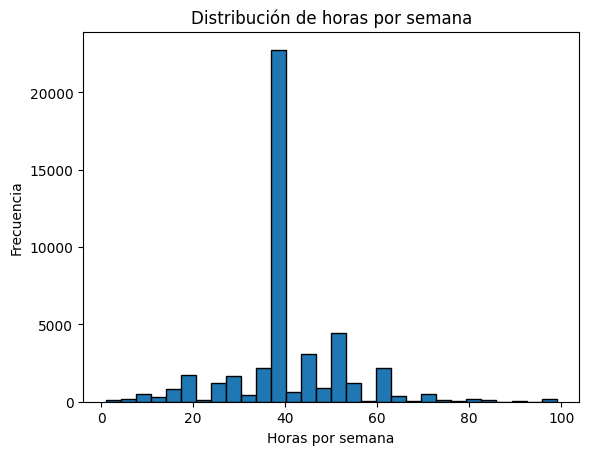

In [11]:
# Visualizemos ahora hour-per-week, para ver si hay outliers, y si es necesario recodificarlo a 40 horas.
plt.hist(data['hours-per-week'], bins=30, edgecolor='black')
plt.xlabel('Horas por semana')
plt.ylabel('Frecuencia')
plt.title('Distribución de horas por semana')
plt.show()

# Puede que exista un outlier en hours-per-week, con maximo de 99 horas,Ya que usamos un Decision Tree, No mejoraremos la variable, ya que el Decision Tree es robusto a outliers.

In [12]:
data.head(10)

,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
7,63,Self-emp-not-inc,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K
10,65,Private,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,6418,0,40,United-States,>50K
11,36,Federal-gov,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States,<=50K


In [13]:
# Usaremos one hot encoding para las variables categoricas, y recodificaremos la variable objetivo income a 0 y 1, donde 0 es <=50K y 1 es >50K.
data = pd.get_dummies(data, columns=['marital-status', 'relationship','race','workclass', 'occupation', 'native-country', 'gender'], drop_first=True)

In [14]:
#Visualizar el nombre de todas las columnas, para ver si es necesario recodificar alguna variable
data.columns

Index(['age', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'income', 'marital-status_Married-AF-spouse',
       'marital-status_Married-civ-spouse',
       'marital-status_Married-spouse-absent', 'marital-status_Never-married',
       'marital-status_Separated', 'marital-status_Widowed',
       'relationship_Not-in-family', 'relationship_Other-relative',
       'relationship_Own-child', 'relationship_Unmarried', 'relationship_Wife',
       'race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White',
       'workclass_Local-gov', 'workclass_Private', 'workclass_Self-emp-inc',
       'workclass_Self-emp-not-inc', 'workclass_State-gov',
       'workclass_Without-pay', 'occupation_Armed-Forces',
       'occupation_Craft-repair', 'occupation_Exec-managerial',
       'occupation_Farming-fishing', 'occupation_Handlers-cleaners',
       'occupation_Machine-op-inspct', 'occupation_Other-service',
       'occupation_Priv-house-serv', 'occupation_Prof-specia

In [15]:
data['income'].head(10)

0     <=50K
1     <=50K
2      >50K
3      >50K
5     <=50K
7      >50K
8     <=50K
9     <=50K
10     >50K
11    <=50K
Name: income, dtype: object

In [16]:
# Recodificamos la variable objetivo income a 0 y 1, donde 0 es <=50K y 1 es >50K.
data['income'] = data['income'].apply(lambda x: 0 if x == '<=50K' else 1)

# Extraer la columna y añadirla al final del DataFrame
data = data.assign(income=data.pop('income'))
data.head(10)


,age,educational-num,capital-gain,capital-loss,hours-per-week,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,...,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,native-country_United-States,gender_Male,income
0,25,7,0,0,40,False,False,False,True,False,...,False,False,False,False,False,False,False,True,True,0
1,38,9,0,0,50,False,True,False,False,False,...,False,False,False,False,False,False,False,True,True,0
2,28,12,0,0,40,False,True,False,False,False,...,False,False,False,True,False,False,False,True,True,1
3,44,10,7688,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,True,1
5,34,6,0,0,30,False,False,False,True,False,...,True,False,False,False,False,False,False,True,True,0
7,63,15,3103,0,32,False,True,False,False,False,...,False,False,True,False,False,False,False,True,True,1
8,24,10,0,0,40,False,False,False,True,False,...,True,False,False,False,False,False,False,True,False,0
9,55,4,0,0,10,False,True,False,False,False,...,False,False,False,False,False,False,False,True,True,0
10,65,9,6418,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,True,1
11,36,13,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,True,0


In [17]:
data.columns

Index(['age', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'marital-status_Married-AF-spouse',
       'marital-status_Married-civ-spouse',
       'marital-status_Married-spouse-absent', 'marital-status_Never-married',
       'marital-status_Separated', 'marital-status_Widowed',
       'relationship_Not-in-family', 'relationship_Other-relative',
       'relationship_Own-child', 'relationship_Unmarried', 'relationship_Wife',
       'race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White',
       'workclass_Local-gov', 'workclass_Private', 'workclass_Self-emp-inc',
       'workclass_Self-emp-not-inc', 'workclass_State-gov',
       'workclass_Without-pay', 'occupation_Armed-Forces',
       'occupation_Craft-repair', 'occupation_Exec-managerial',
       'occupation_Farming-fishing', 'occupation_Handlers-cleaners',
       'occupation_Machine-op-inspct', 'occupation_Other-service',
       'occupation_Priv-house-serv', 'occupation_Prof-specialty',
    

In [18]:
# Realizare un guardado del dataset limpio en un archivo CSV, para poder visualizarlo y que todo este correcto, y luego poder usarlo para entrenar el modelo de Decision Tree.
data.to_csv('adult_clean.csv', index=False)

In [19]:
# Todo parece correcto a este punto. es hora de crear un dataset balanceado.
# Revisemos como esta el balance de la variable objetivo income, para ver si es necesario balancear el dataset.
data['income'].value_counts(normalize=True)

# Aun que el dataset esta algo desbalanceado, podemos usarlo tal cual para entrenar el modelo de Decision Tree, ya que este algoritmo es robusto a datasets desbalanceados.
# Incluso podemosar usar class_weight='balanced' en el modelo de Decision Tree para mejorar el rendimiento del modelo en datasets desbalanceados.
# Por lo que ahora pasaremos a entrenar desde un script de python, para poder usar el dataset limpio y balanceado, y entrenar el modelo de Decision Tree.

income
0    0.751874
1    0.248126
Name: proportion, dtype: float64

In [20]:
# Limpiamos la memoria, eliminando las variables que ya no necesitamos.
del data

### Phase B: Model Building

Train a baseline Decision Tree classifier using the training partition.

Analyze the initial splitting criteria and structure generated by the algorithm. 

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [22]:
# Carga de datos
data = pd.read_csv('adult_clean.csv')

X = data.drop('income', axis=1)
y = data['income']

# Dividimos las características y el target en conjuntos de entrenamiento (80%) y prueba (20%).
# - test_size=0.2: 80% para entrenar y aprender las reglas, 20% para validar la precisión final.
# - random_state=42: Semilla aleatoria fija que garantiza que la división sea reproducible (mismas particiones siempre).
# - stratify=y: Indispensable debido al desbalanceo de clases (~75% vs ~25%). Garantiza que ambos subconjuntos
#   de datos contengan la misma proporción exacta de personas con altos y bajos ingresos.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

classifier = DecisionTreeClassifier(random_state=42, class_weight='balanced')
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

In [23]:
# Vamos a analizar la estructura del árbol generado y la importancia de las variables para entender cómo el modelo está tomando decisiones.

# Extraemos métricas de la estructura del árbol
max_depth = classifier.tree_.max_depth
leaves = classifier.get_n_leaves()
total_nodes = classifier.tree_.node_count

print(f"Profundidad máxima del árbol: {max_depth}")
print(f"Número de nodos hoja (reglas finales): {leaves}")
print(f"Número total de nodos en el árbol: {total_nodes}")

# Un árbol con una profundidad de más de 40 niveles y miles de hojas
# está claramente memorizando el conjunto de entrenamiento (sobreajuste).

feature_names = X_train.columns

# Análisis del Nodo Raíz a bajo nivel (Initial Splitting Criteria)
internal_tree = classifier.tree_
root_node = 0

feature_idx = internal_tree.feature[root_node]
feature_name = feature_names[feature_idx]
threshold = internal_tree.threshold[root_node]
impurity = internal_tree.impurity[root_node]
samples = internal_tree.n_node_samples[root_node]

print("\nCriterio de División Inicial (Root Node)")
print(f"Característica seleccionada : {feature_name}")
print(f"Valor umbral (Threshold)    : <= {threshold:.4f}")
print(f"Impureza inicial (Gini)     : {impurity:.4f}")
print(f"Total de muestras evaluadas : {samples}")

Profundidad máxima del árbol: 46
Número de nodos hoja (reglas finales): 7236
Número total de nodos en el árbol: 14471

Criterio de División Inicial (Root Node)
Característica seleccionada : marital-status_Married-civ-spouse
Valor umbral (Threshold)    : <= 0.5000
Impureza inicial (Gini)     : 0.5000
Total de muestras evaluadas : 36826



Estructura inicial de reglas lógicas (Top 2 niveles):
|--- marital-status_Married-civ-spouse <= 0.50
|   |--- capital-gain <= 7073.50
|   |   |--- educational-num <= 12.50
|   |   |   |--- truncated branch of depth 31
|   |   |--- educational-num >  12.50
|   |   |   |--- truncated branch of depth 31
|   |--- capital-gain >  7073.50
|   |   |--- age <= 20.00
|   |   |   |--- truncated branch of depth 2
|   |   |--- age >  20.00
|   |   |   |--- truncated branch of depth 6
|--- marital-status_Married-civ-spouse >  0.50
|   |--- educational-num <= 11.50
|   |   |--- capital-gain <= 5095.50
|   |   |   |--- truncated branch of depth 44
|   |   |--- capital-gain >  5095.50
|   |   |   |--- truncated branch of depth 8
|   |--- educational-num >  11.50
|   |   |--- capital-gain <= 5095.50
|   |   |   |--- truncated branch of depth 41
|   |   |--- capital-gain >  5095.50
|   |   |   |--- truncated branch of depth 4



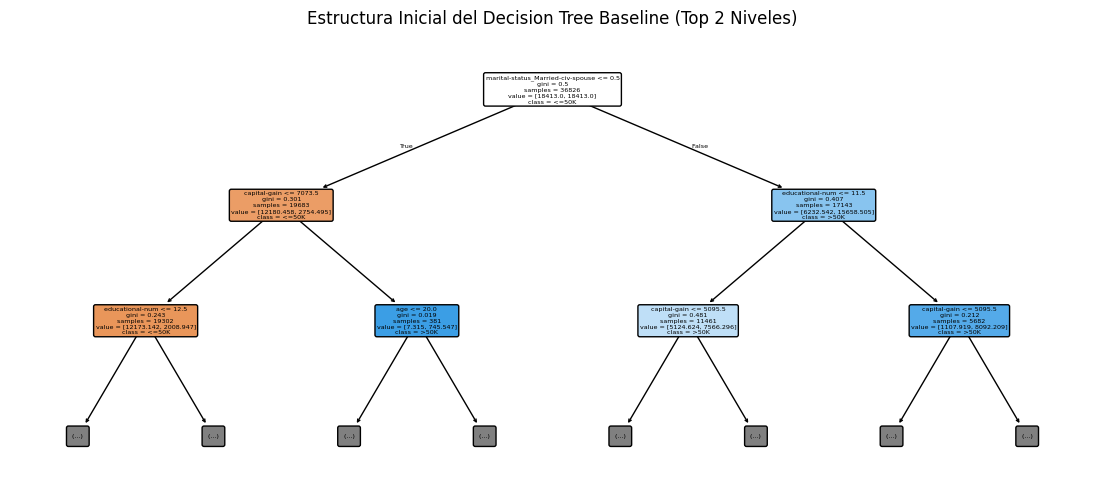

In [24]:
#Inspección de la Estructura Inicial (Top-Level Structure)
print("\nEstructura inicial de reglas lógicas (Top 2 niveles):")
tree_rules = export_text(classifier, feature_names=list(feature_names), max_depth=2)
print(tree_rules)

# Representación gráfica en ventana emergente (profundidad 2)
plt.figure(figsize=(14, 6))
plot_tree(classifier,
          feature_names=feature_names,
          class_names=['<=50K', '>50K'],
          filled=True,
          rounded=True,
          max_depth=2)
plt.title("Estructura Inicial del Decision Tree Baseline (Top 2 Niveles)")
plt.show()

# La variable que maximiza la ganancia de información inicial es 'marital-status_Married-civ-spouse'.
# El algoritmo divide primero a la población entre casados y no casados, siendo el predictor más fuerte de altos ingresos.
# El Gini de 0.5000 confirma que el parámetro class_weight='balanced' está funcionando,forzando una distribución de pesos 50/50 en el nodo raíz.
# Jerarquía Lógica: Los siguientes niveles (Depth 1 y 2) priorizan variables socioeconómicas clave como los años de educación (educational-num), edad (age) y capital neto (capital-net).
# La estructura muestra ramas que continúan hasta 44 niveles adicionales, lo que indica un sobreajuste  al conjunto de entrenamiento.

### Phase C: Model Evaluation

Rigorously evaluate model performance using standard classification metrics: Accuracy, Precision,

Recall, F1-Score, and the Confusion Matrix.

Apply the trained model to the testing set and explicitly compare predicted values against actual groundtruth values.

Identify and discuss signs of overfitting or underfitting based on training vs. test metrics.

In [25]:
y_pred_test = classifier.predict(X_test)
y_pred_train = classifier.predict(X_train)
# Extracción de Accuracy para comparación directa
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy en Entrenamiento : {acc_train:.4f}")
print(f"Accuracy en Prueba        : {acc_test:.4f}")
print(f"Caída de rendimiento      : {(acc_train - acc_test):.4f}\n")


# Se puede observar que el modelo esta sobreajustado (overfitting) al conjunto de entrenamiento, con una caída de rendimiento del 17.85% al evaluar en el conjunto de prueba.


print("Classification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Podemos observar que el modelo tiene un buen desempeño en la clase mayoritaria (0: <=50K),
# pero un desempeño más bajo en la clase minoritaria (1: >50K).
#  class_weight='balanced' ayuda a mejorar la sensibilidad hacia la clase minoritaria.
# Recall (0.63): El modelo logra capturar el 63% de todos los casos positivos reales.
# Precision (0.55):  Por cada 100 individuos que el árbol clasifica con altos ingresos, 45 en realidad pertenecen a la clase mayoritaria.  error de Tipo I.


Accuracy en Entrenamiento : 0.9650
Accuracy en Prueba        : 0.8051
Caída de rendimiento      : 0.1598

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87      6923
           1       0.60      0.67      0.63      2284

    accuracy                           0.81      9207
   macro avg       0.74      0.76      0.75      9207
weighted avg       0.81      0.81      0.81      9207


Confusion Matrix:
[[5884 1039]
 [ 755 1529]]


### Phase D: Hyperparameter Tuning

Experiment with key tree hyperparameters (e.g., maximum depth max_depth, minimum samples required

to split a node min_samples_split, or impurity criteria: Gini vs. Entropy) to optimize classification

boundaries.


In [26]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

param_distributions = {
    'max_depth': [None, 5, 10, 15, 20, 25, 30],
    'min_samples_split': [2, 10, 50, 100, 200],
    'min_samples_leaf': [1, 10, 20, 50, 100],
    'max_features': [None, 'sqrt', 'log2']
}

# cv=5: Validación cruzada de 5 pliegues para garantizar robustez en la evaluación.
# scoring='f1_macro': Penalizamos al modelo si ignora la clase minoritaria (>50K).
# n_jobs=-1: Utiliza todos los núcleos del procesador para paralelizar la búsqueda.

tree_b = DecisionTreeClassifier(criterion='gini', class_weight='balanced', random_state=42)

random_search =  RandomizedSearchCV(estimator=tree_b, param_distributions=param_distributions, n_iter=300, cv=5, scoring='f1', random_state=42, n_jobs=-1)

random_search.fit(X_train, y_train)
best_tree = random_search.best_estimator_

print("Mejores hiperparámetros encontrados:")
for param, value in random_search.best_params_.items():
    print(f" - {param}: {value}")

Mejores hiperparámetros encontrados:
 - min_samples_split: 200
 - min_samples_leaf: 10
 - max_features: None
 - max_depth: None


In [27]:
y_pred_train_best = best_tree.predict(X_train)
y_pred_test_best = best_tree.predict(X_test)

acc_train_best = accuracy_score(y_train, y_pred_train_best)
acc_test_best = accuracy_score(y_test, y_pred_test_best)


print(f"Accuracy en Entrenamiento : {acc_train_best:.4f}")
print(f"Accuracy en Prueba        : {acc_test_best:.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred_test_best, target_names=['<=50K', '>50K']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_best))

print(f"\nNueva profundidad máxima: {best_tree.tree_.max_depth}")
print(f"Nuevo número de hojas: {best_tree.get_n_leaves()}")

# Podemos observar que el modelo ha mejorado bastante, con casi nada de sobreajuste,
# y un mejor desempeño en la clase minoritaria (>50K), con un recall de 0.70 y precision de 0.60,
#  lo que indica que el modelo es capaz de capturar más casos positivos reales y reducir los falsos positivos.

Accuracy en Entrenamiento : 0.8286
Accuracy en Prueba        : 0.8144
Classification Report:
              precision    recall  f1-score   support

       <=50K       0.94      0.81      0.87      6923
        >50K       0.59      0.83      0.69      2284

    accuracy                           0.81      9207
   macro avg       0.76      0.82      0.78      9207
weighted avg       0.85      0.81      0.82      9207

Confusion Matrix:
[[5602 1321]
 [ 388 1896]]

Nueva profundidad máxima: 29
Nuevo número de hojas: 369


### Phase E: Interpretation & Insights

Graphically visualize the final decision tree structure (or a representative section if it is too dense) to understand the underlying logical rules.

Identify and report feature importance to determine which attributes carry the highest predictive power for each dataset.


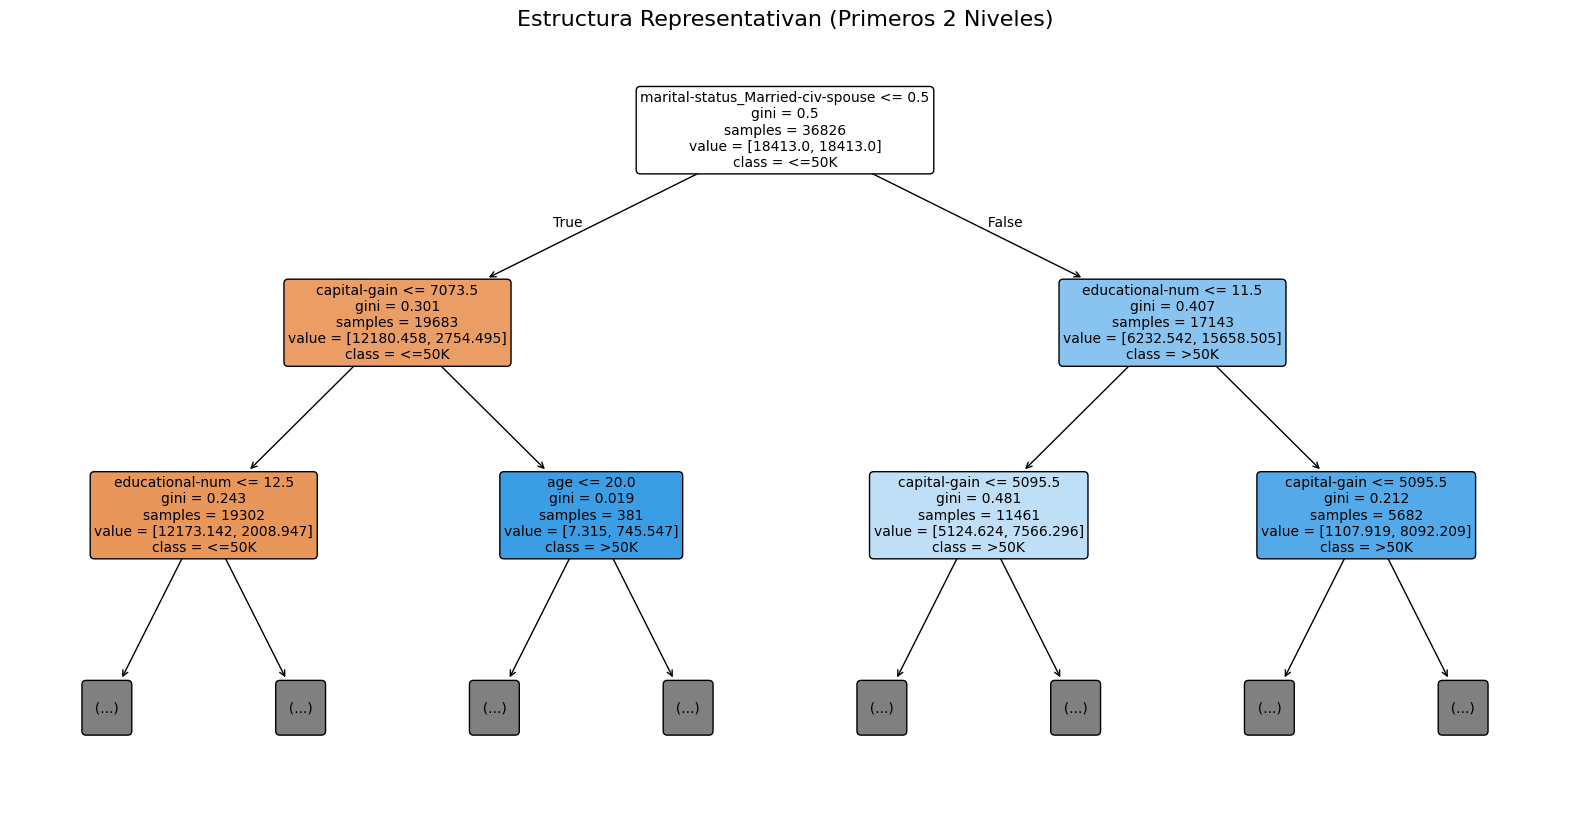

In [28]:
plt.figure(figsize=(20, 10))
plot_tree(classifier,
          max_depth=2,
          feature_names=X_train.columns,
          class_names=['<=50K', '>50K'],
          filled=True,
          rounded=True,
          fontsize=10)

plt.title("Estructura Representativan (Primeros 2 Niveles)", fontsize=16)
plt.show()

# Podemos visualizar las primeras 2 niveles del árbol, para ver como el modelo esta tomando decisiones,
#  como las variables socioeconómicas son las más importantes para predecir los ingresos.

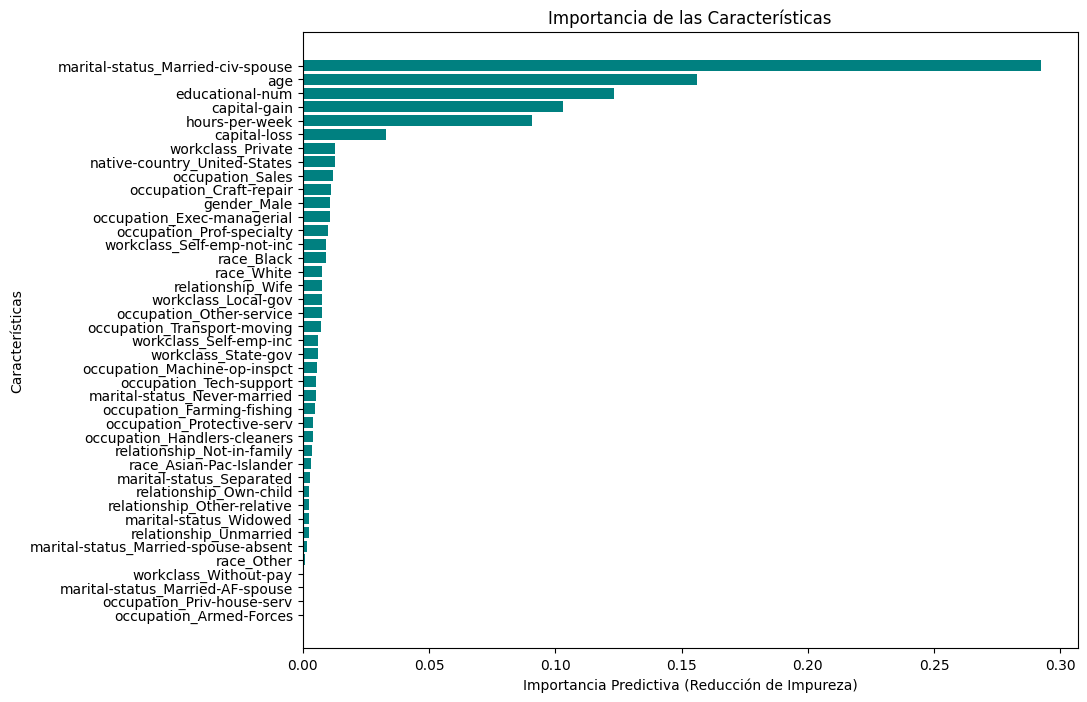

In [29]:
importances = classifier.feature_importances_

df_importances = pd.DataFrame({
    'Característica': X_train.columns,
    'Importancia': importances
})

df_importances = df_importances.sort_values(by='Importancia', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(df_importances['Característica'], df_importances['Importancia'], color='teal')
plt.xlabel('Importancia Predictiva (Reducción de Impureza)')
plt.ylabel('Características')
plt.title('Importancia de las Características')
plt.show()

# las Características socioeconómicas como marital-status, educational-num, age y capital-net son las más importantes para predecir los ingresos,
#  mientras que características como race, gender y native-country tienen una importancia predictiva mucho menor, lo que indica que el modelo está priorizando factores socioeconómicos sobre demográficos para determinar los ingresos.

In [30]:
# Por ultimo guardare el modelo entrenado en un archivo joblib para poder usarlo en un script de python y hacer predicciones sobre nuevos datos.
import joblib
joblib.dump(best_tree, 'adult_income_decision_tree.joblib',compress=3)


['adult_income_decision_tree.joblib']